# Data Cleaning

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [6]:
file_path=r"C:\Users\admin\Desktop\Intern\Week 9\Online Retail Sales Analysis\data\Retail.xlsx"
df=pd.read_excel(file_path)
print("Dataset loaded successfully! ")
print("Shape:",df.shape)
df.head()

Dataset loaded successfully! 
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [7]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Rows and Columns:
(541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows:
5268


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,"541,909.00","25,900.00","573,585.00","1,114.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"541,909.00",NaN,NaN,NaN,9.55,"-80,995.00",1.00,3.00,10.00,"80,995.00",218.08
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,"541,909.00",NaN,NaN,NaN,4.61,"-11,062.06",1.25,2.08,4.13,"38,970.00",96.76
CustomerID,"406,829.00",NaN,NaN,NaN,"15,287.69","12,346.00","13,953.00","15,152.00","16,791.00","18,287.00","1,713.60"
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Make a copy of the raw data
cleaned_df = df.copy()

# Remove exact duplicate rows
cleaned_df = cleaned_df.drop_duplicates()

# Convert InvoiceDate to datetime
cleaned_df["InvoiceDate"] = pd.to_datetime(
    cleaned_df["InvoiceDate"],
    errors="coerce"
)

# Identify cancellations
cleaned_df["TransactionStatus"] = np.where(
    cleaned_df["Quantity"] < 0,
    "Cancellation",
    "Sale"
)

# Create revenue
cleaned_df["Revenue"] = (
    cleaned_df["Quantity"] * cleaned_df["UnitPrice"]
)

# Create cancellation amount
cleaned_df["CancellationAmount"] = np.where(
    cleaned_df["Quantity"] < 0,
    abs(cleaned_df["Revenue"]),
    0
)

# Create date-related columns
cleaned_df["Year"] = cleaned_df["InvoiceDate"].dt.year
cleaned_df["Month"] = cleaned_df["InvoiceDate"].dt.month
cleaned_df["MonthName"] = cleaned_df["InvoiceDate"].dt.strftime("%b")
cleaned_df["YearMonth"] = cleaned_df["InvoiceDate"].dt.to_period("M").astype(str)

print(cleaned_df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  \
0 2010-12-01 08:26:00       2.55   17,850.00  United Kingdom   
1 2010-12-01 08:26:00       3.39   17,850.00  United Kingdom   
2 2010-12-01 08:26:00       2.75   17,850.00  United Kingdom   
3 2010-12-01 08:26:00       3.39   17,850.00  United Kingdom   
4 2010-12-01 08:26:00       3.39   17,850.00  United Kingdom   

  TransactionStatus  Revenue  CancellationAmount  Year  Month MonthName  \
0              Sale    15.30                0.00  2010     12       Dec   
1              Sale    20.34    

In [10]:
sales_df = cleaned_df[
    (cleaned_df["TransactionStatus"] == "Sale") &
    (cleaned_df["UnitPrice"] > 0) &
    (cleaned_df["Quantity"] > 0)
].copy()

In [11]:
print("Original rows:", len(df))
print("After duplicate removal:", len(cleaned_df))

print("\nTransaction Status:")
print(cleaned_df["TransactionStatus"].value_counts())

print("\nMissing Values:")
print(cleaned_df.isnull().sum())

print("\nInvalid prices:")
print((cleaned_df["UnitPrice"] <= 0).sum())

print("\nSales dataset:", sales_df.shape)

Original rows: 541909
After duplicate removal: 536641

Transaction Status:
TransactionStatus
Sale            526054
Cancellation     10587
Name: count, dtype: int64

Missing Values:
InvoiceNo                  0
StockCode                  0
Description             1454
Quantity                   0
InvoiceDate                0
UnitPrice                  0
CustomerID            135037
Country                    0
TransactionStatus          0
Revenue                    0
CancellationAmount         0
Year                       0
Month                      0
MonthName                  0
YearMonth                  0
dtype: int64

Invalid prices:
2512

Sales dataset: (524878, 15)


In [12]:
output_path = r"C:\Users\admin\Desktop\Intern\Week 9\Online Retail Sales Analysis\data\Retail.csv"

cleaned_df.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [13]:
# Identify cancelled invoices
cleaned_df["IsCancellation"] = (
    cleaned_df["InvoiceNo"].astype(str).str.startswith("C")
)

# Valid sales transactions
sales_df = cleaned_df[
    (~cleaned_df["IsCancellation"]) &
    (cleaned_df["Quantity"] > 0) &
    (cleaned_df["UnitPrice"] > 0)
].copy()

print("Valid sales transactions:", len(sales_df))
print("Total revenue:", sales_df["Revenue"].sum())

Valid sales transactions: 524878
Total revenue: 10642110.804


# Business KPI

In [14]:
total_revenue = sales_df["Revenue"].sum()
total_quantity = sales_df["Quantity"].sum()
total_orders = sales_df["InvoiceNo"].nunique()
total_customers = sales_df["CustomerID"].nunique()
total_products = sales_df["StockCode"].nunique()

aov = total_revenue / total_orders

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Average Order Value: £{aov:,.2f}")

Total Revenue: £10,642,110.80
Total Quantity Sold: 5,572,420
Total Orders: 19,960
Total Customers: 4,338
Total Products: 3,922
Average Order Value: £533.17


# Monthly Revenue Trend

In [15]:
monthly_sales=(
    sales_df.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)
monthly_sales

,YearMonth,Revenue
0,2010-12,"821,452.73"
1,2011-01,"689,811.61"
2,2011-02,"522,545.56"
3,2011-03,"716,215.26"
4,2011-04,"536,968.49"
5,2011-05,"769,296.61"
6,2011-06,"760,547.01"
7,2011-07,"718,076.12"
8,2011-08,"757,841.38"
9,2011-09,"1,056,435.19"


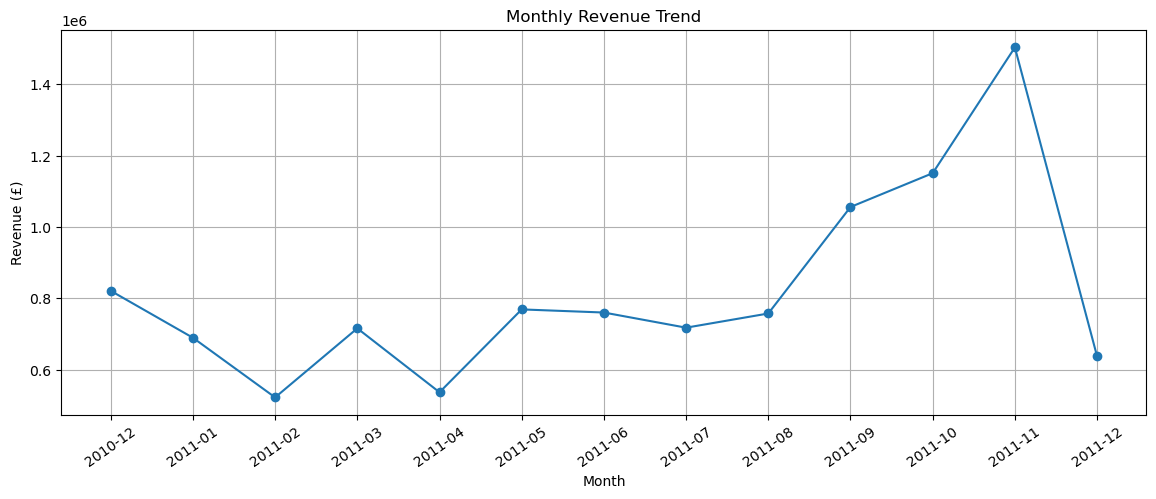

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=35)
plt.grid(True)

plt.show()

# Revenue By Country

In [17]:
country_sales = (
    sales_df.groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum"),
        Customers=("CustomerID", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

country_sales.head(10)

,Revenue,Orders,Quantity,Customers
Country,,,,
United Kingdom,"9,001,744.09",18019,4646906,3920
Netherlands,"285,446.34",94,200361,9
EIRE,"283,140.52",288,147007,3
Germany,"228,678.40",457,119154,94
France,"209,625.37",392,112060,87
Australia,"138,453.81",57,83891,9
Spain,"61,558.56",90,27933,30
Switzerland,"57,067.60",54,30617,21
Belgium,"41,196.34",98,23237,25


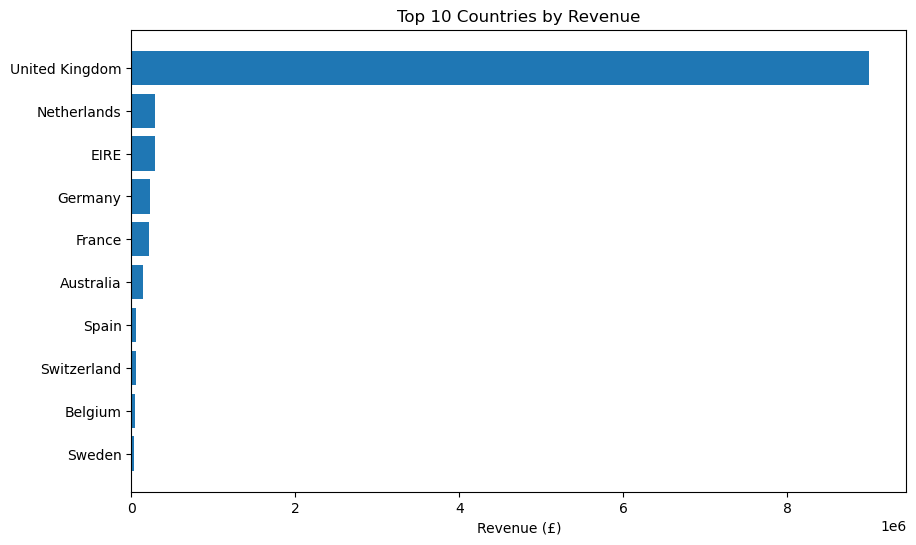

In [18]:
top_countries = country_sales.head(10).sort_values("Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries.index,
    top_countries["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")

plt.show()

# Top Products

In [19]:
product_sales = (
    sales_df.groupby(["StockCode", "Description"])
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

product_sales.head(10)

,StockCode,Description,Revenue,Quantity,Orders
4150,DOT,DOTCOM POSTAGE,"206,248.77",706,706
1262,22423,REGENCY CAKESTAND 3 TIER,"174,156.54",13851,1988
2590,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,284.24",37580,2189
2669,47566,PARTY BUNTING,"99,445.23",18283,1685
3761,85099B,JUMBO BAG RED RETROSPOT,"94,159.81",48371,2089
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247
4153,POST,POSTAGE,"78,101.88",3150,1126
4151,M,Manual,"77,750.27",6984,289
1951,23084,RABBIT NIGHT LIGHT,"66,870.03",30739,994


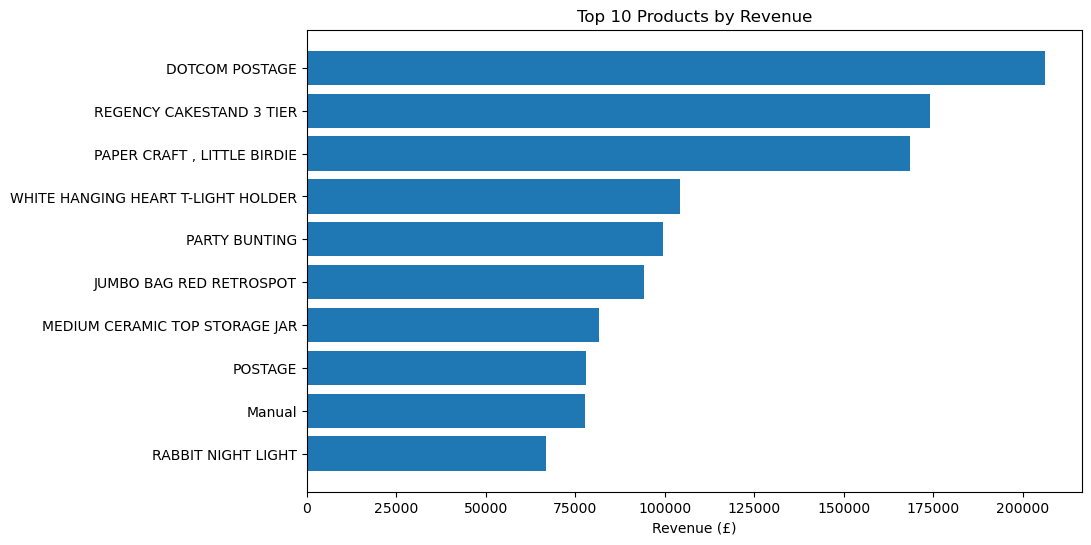

In [20]:
top_products = product_sales.head(10).sort_values("Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Description"],
    top_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")

plt.show()

# Customer Analysis

In [21]:
customer_sales = (
    sales_df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

customer_sales.head(10)

,Revenue,Orders,Quantity
CustomerID,,,
"14,646.00","280,206.02",73,196915
"18,102.00","259,657.30",60,64124
"17,450.00","194,390.79",46,69973
"16,446.00","168,472.50",2,80997
"14,911.00","143,711.17",201,80240
"12,415.00","124,914.53",21,77374
"14,156.00","117,210.08",55,57768
"17,511.00","91,062.38",31,64549
"16,029.00","80,850.84",63,40108


# Cancellation Analysis

In [22]:
cancellation_df = cleaned_df[
    cleaned_df["IsCancellation"]
].copy()

total_cancellations = cancellation_df["InvoiceNo"].nunique()

cancellation_value = cancellation_df["CancellationAmount"].sum()

print("Cancelled Orders:", total_cancellations)
print(f"Cancellation Value: £{cancellation_value:,.2f}")

Cancelled Orders: 3836
Cancellation Value: £893,979.73


# Cancellation Rate

In [23]:
cancellation_rate = (
    total_cancellations / total_orders
) * 100

print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Cancellation Rate: 19.22%


# Revenue,Orders,AOV by Month

In [24]:
monthly_analysis = (
    sales_df.groupby("YearMonth")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

monthly_analysis["AOV"] = (
    monthly_analysis["Revenue"] /
    monthly_analysis["Orders"]
)

monthly_analysis

,YearMonth,Revenue,Orders,Quantity,AOV
0,2010-12,"821,452.73",1559,358019,526.91
1,2011-01,"689,811.61",1086,387099,635.19
2,2011-02,"522,545.56",1100,282934,475.04
3,2011-03,"716,215.26",1454,376599,492.58
4,2011-04,"536,968.49",1246,307953,430.95
5,2011-05,"769,296.61",1681,395001,457.64
6,2011-06,"760,547.01",1533,388511,496.12
7,2011-07,"718,076.12",1475,399693,486.83
8,2011-08,"757,841.38",1361,421020,556.83
9,2011-09,"1,056,435.19",1837,569573,575.09


# Cancellation by Month

In [25]:
cancellation_monthly = (
    cancellation_df.groupby("YearMonth")
    .agg(
        Cancelled_Orders=("InvoiceNo", "nunique"),
        Cancellation_Value=("CancellationAmount", "sum")
    )
    .reset_index()
)

cancellation_monthly

,YearMonth,Cancelled_Orders,Cancellation_Value
0,2010-12,326,"74,729.12"
1,2011-01,260,"131,363.05"
2,2011-02,219,"25,519.15"
3,2011-03,318,"34,201.28"
4,2011-04,240,"44,600.65"
5,2011-05,314,"47,202.51"
6,2011-06,329,"70,569.78"
7,2011-07,270,"37,919.13"
8,2011-08,278,"54,330.80"
9,2011-09,333,"38,838.51"


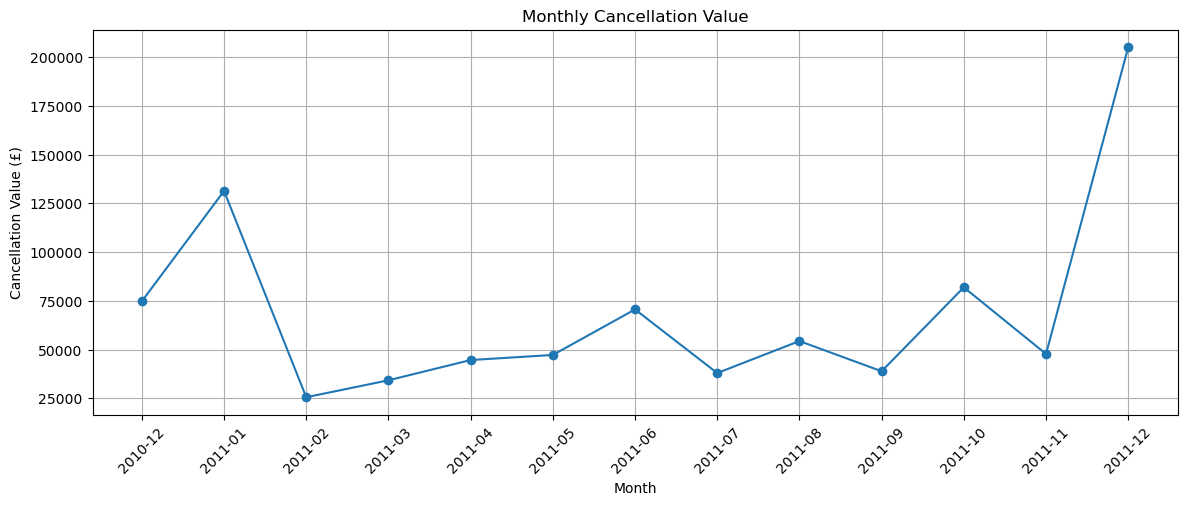

In [26]:
plt.figure(figsize=(14, 5))

plt.plot(
    cancellation_monthly["YearMonth"],
    cancellation_monthly["Cancellation_Value"],
    marker="o"
)

plt.title("Monthly Cancellation Value")
plt.xlabel("Month")
plt.ylabel("Cancellation Value (£)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# Customer Concentration

In [27]:
customer_sales = (
    sales_df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

top_10_customer_revenue = customer_sales.head(10)["Revenue"].sum()

customer_revenue_share = (
    top_10_customer_revenue /
    customer_sales["Revenue"].sum()
) * 100

print(f"Top 10 customers revenue: £{top_10_customer_revenue:,.2f}")
print(f"Top 10 customer revenue share: {customer_revenue_share:.2f}%")

Top 10 customers revenue: £1,537,659.21
Top 10 customer revenue share: 17.30%


# Merchandise vs Non-Merchandise

In [28]:
non_merchandise_keywords = [
    "POSTAGE",
    "MANUAL",
    "BANK CHARGES",
    "DOTCOM POSTAGE",
    "AMAZON FEE"
]

sales_df["ProductType"] = np.where(
    sales_df["Description"]
    .str.upper()
    .str.contains("|".join(non_merchandise_keywords), na=False),
    "Non-Merchandise",
    "Merchandise"
)

sales_df["ProductType"].value_counts()

ProductType
Merchandise        522715
Non-Merchandise      2163
Name: count, dtype: int64

In [29]:
product_type_analysis = (
    sales_df.groupby("ProductType")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
)

product_type_analysis

,Revenue,Quantity,Orders
ProductType,,,
Merchandise,"10,266,081.24",5561565,19779
Non-Merchandise,"376,029.56",10855,2132


In [30]:
sales_df["CustomerID"] = sales_df["CustomerID"].astype("Int64")

sales_df.to_csv(
    r"C:\Users\admin\Desktop\Intern\Week 9\Online Retail Sales Analysis\data\Retail.csv",
    index=False,
    na_rep=""
)

In [31]:
cleaned_df.to_csv(
     r"C:\Users\admin\Desktop\Intern\Week 9\Online Retail Sales Analysis\data\Retail2.csv",
    index=False
)